
**Important First Step in Colab:**
Make sure to enable a GPU runtime for faster training:
1.  Go to **Runtime** in the Colab menu.
2.  Select **Change runtime type**.
3.  Choose **GPU** from the Hardware accelerator dropdown and click **Save**.



---

### Cell 1: Setup - Install Libraries (if needed) and Imports

In [2]:
# PyTorch and Torchvision are usually pre-installed in Colab.
# If you need a specific version or other libraries, uncomment and run:

# !pip install pillow numpy
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, models
from torch.utils.data import DataLoader, Dataset, ConcatDataset
import numpy as np
import os
import zipfile
from PIL import Image
from tqdm.notebook import tqdm # For progress bars in Colab

# Check if GPU is available
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# For reproducibility (optional, but good practice)
torch.manual_seed(42)
np.random.seed(42)
if DEVICE == 'cuda':
    torch.cuda.manual_seed_all(42)
PACS_DOMAINS = ['art_painting', 'cartoon', 'photo', 'sketch']
PACS_CATEGORIES = ['dog', 'elephant', 'giraffe', 'guitar', 'horse', 'house', 'person']

# ========================
# 🔧 Experiment Hyperparameters
# ========================
MODEL_CHOICE = 'resnet18'
PRETRAINED = True
NUM_EPOCHS = 10
BATCH_SIZE = 32
LEARNING_RATE = 3e-5

# 👇 This helps identify logs/models when saving
print(f"Using device: {DEVICE}, Model: {MODEL_CHOICE}, Epochs: {NUM_EPOCHS}, Batch: {BATCH_SIZE}, LR: {LEARNING_RATE}")


Using device: cuda
Using device: cuda, Model: resnet18, Epochs: 10, Batch: 32, LR: 3e-05


---

### Cell 2: Download and Prepare PACS Dataset

The PACS dataset needs to be downloaded. Here's a common way to get it. We'll download it directly into the Colab environment. If you have it on Google Drive, you can mount your Drive and adjust the path.

In [3]:
# Cell 2: Load and Extract PACS Dataset (Ultra-Minimal - Command Style)

import os
import zipfile
from google.colab import drive

# --- Configuration (Must be perfectly correct and file must exist at the specified path) ---
GOOGLE_DRIVE_FILE_PATH = "/content/drive/MyDrive/Colab Notebooks/PACS.zip"
COLAB_ZIP_NAME = "PACS.zip"
BASE_PACS_PATH = "kfold" # This must be the main folder name after unzipping
# --- End Configuration ---

# 1. Mount Google Drive
# Using force_remount to ensure a fresh mount attempt each time
drive.mount('/content/drive', force_remount=True)

# 2. Copy from Google Drive
os.system(f"cp '{GOOGLE_DRIVE_FILE_PATH}' {COLAB_ZIP_NAME}")

# 3. Unzip
with zipfile.ZipFile(COLAB_ZIP_NAME, 'r') as zip_ref:
    zip_ref.extractall(".") # Extract to current directory

# Keeping this final print so you know the value of BASE_PACS_PATH:
print(f"Dataset base path is configured as: '{BASE_PACS_PATH}'")

Mounted at /content/drive
Dataset base path is configured as: 'kfold'


---

### Cell 3: PACS_Dataset Class and Transformations





In [4]:
from pathlib import Path
# Assuming Dataset, Image, transforms are imported in Cell 1 or globally available

class PACS_Dataset(Dataset):
    def __init__(self, base_path, domain_name, categories, transform=None):
        self.transform = transform
        self.image_paths = []
        self.labels = []
        for label_idx, category in enumerate(categories):
            category_path = os.path.join(base_path, domain_name, category)
            if not os.path.isdir(category_path):
                continue
            for img_file in os.listdir(category_path):
                if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                    self.image_paths.append(os.path.join(category_path, img_file))
                    self.labels.append(label_idx)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB')
        label = self.labels[idx]
        if self.transform:
            img = self.transform(img)
        return img, label

# --- Data Transformations (No Augmentation for train_transform) ---
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

# Train transform simplified to match validation/test (no data augmentation)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

---

### Cell 4: Model Definition (ResNet 18)

In [5]:
def get_model(num_classes=len(PACS_CATEGORIES), pretrained=True):
    # Load the ResNet18 model with optional ImageNet pretrained weights
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1 if pretrained else None)

    # Replace the final fully connected layer to match the number of target classes
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, num_classes)

    return model
# Test model creation
try:
    test_model = get_model(num_classes=len(PACS_CATEGORIES))
    print("Model created successfully.")
    # print(test_model)  # Uncomment this line to view the model architecture
except Exception as e:
    print(f"Error creating model: {e}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 71.0MB/s]

Model created successfully.


---

### Cell 5: Training and Evaluation Functions

In [6]:
# 训练函数
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for inputs, labels in tqdm(dataloader, desc="Train", leave=False):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        preds = outputs.argmax(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total

# 验证函数
def eval_one_epoch(model, dataloader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in tqdm(dataloader, desc="Val", leave=False):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * inputs.size(0)
            preds = outputs.argmax(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return running_loss / total, correct / total


---

### Cell 6: Leave-One-Domain-Out Evaluation Pipeline

In [11]:
import json
import os

BASE_PACS_PATH = "kfold"
all_accuracies = []

for target_domain in PACS_DOMAINS:
    print(f"\n===== Target Domain = {target_domain} =====")
    source_domains = [d for d in PACS_DOMAINS if d != target_domain]
    # 合并所有 source domain 数据
    train_datasets = [
        PACS_Dataset(BASE_PACS_PATH, d, PACS_CATEGORIES, transform=train_transform)
        for d in source_domains
    ]
    train_dataset = torch.utils.data.ConcatDataset(train_datasets)
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

    test_dataset = PACS_Dataset(BASE_PACS_PATH, target_domain, PACS_CATEGORIES, transform=val_test_transform )
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    model = get_model(len(PACS_CATEGORIES), PRETRAINED).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

    best_val_acc = 0.0

    for epoch in range(NUM_EPOCHS):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
        val_loss, val_acc = eval_one_epoch(model, test_loader, criterion, DEVICE)
        print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Train Acc: {train_acc:.3f} | Val Acc: {val_acc:.3f}")
        best_val_acc = max(best_val_acc, val_acc)

    all_accuracies.append(best_val_acc)

average_acc = sum(all_accuracies) / len(all_accuracies)
worst_acc = min(all_accuracies)

print("\n===== Cross-Domain Evaluation Summary =====")
for domain, acc in zip(PACS_DOMAINS, all_accuracies):
    print(f"{domain}: {acc:.3f}")
print(f"\nAverage Accuracy: {average_acc:.3f}")
print(f"Worst-case Accuracy: {worst_acc:.3f}")

os.makedirs("results", exist_ok=True)

# 构造保存数据结构
baseline_results = {
    "type": "baseline",
    "domains": PACS_DOMAINS,
    "accuracies": all_accuracies,
    "average": average_acc,
    "worst_case": worst_acc
}

# 保存为 JSON 文件
with open("results/baseline_results.json", "w") as f:
    json.dump(baseline_results, f, indent=4)

print("\n✅ Baseline results saved to 'results/baseline_results.json'")




===== Target Domain = art_painting =====


Train:   0%|          | 0/249 [00:00<?, ?it/s]

Val:   0%|          | 0/64 [00:00<?, ?it/s]

Epoch 1/10 | Train Acc: 0.810 | Val Acc: 0.757


Train:   0%|          | 0/249 [00:00<?, ?it/s]

...

Val:   0%|          | 0/123 [00:00<?, ?it/s]

Epoch 9/10 | Train Acc: 1.000 | Val Acc: 0.629


Train:   0%|          | 0/190 [00:00<?, ?it/s]

Val:   0%|          | 0/123 [00:00<?, ?it/s]

Epoch 10/10 | Train Acc: 1.000 | Val Acc: 0.627

===== Cross-Domain Evaluation Summary =====
art_painting: 0.774
cartoon: 0.747
photo: 0.941
sketch: 0.629

Average Accuracy: 0.773
Worst-case Accuracy: 0.629

✅ Baseline results saved to 'results/baseline_results.json'


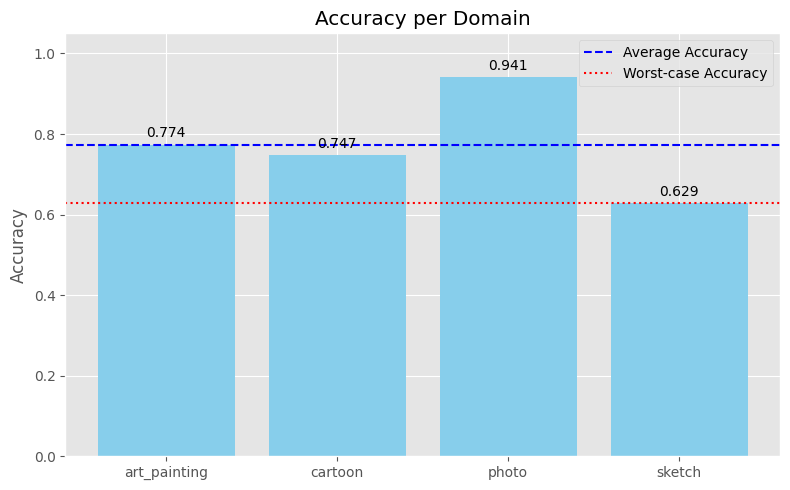

In [12]:
import matplotlib.pyplot as plt

# 如果你在另一个 Cell 运行，请确保这两个变量已定义
# 示例：
# PACS_DOMAINS = ['art_painting', 'cartoon', 'photo', 'sketch']
# all_accuracies = [0.812, 0.774, 0.855, 0.723]  # 用你自己训练得到的值替换

average_acc = sum(all_accuracies) / len(all_accuracies)
worst_acc = min(all_accuracies)

plt.style.use('ggplot')
plt.figure(figsize=(8, 5))
bars = plt.bar(PACS_DOMAINS, all_accuracies, color='skyblue')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.01, f'{yval:.3f}', ha='center', va='bottom')

plt.axhline(average_acc, color='blue', linestyle='--', label='Average Accuracy')
plt.axhline(worst_acc, color='red', linestyle=':', label='Worst-case Accuracy')

plt.title("Accuracy per Domain")
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()
